# Latent structure in Human Protein Atlas embeddings of plasma membrane-associated proteins

This notebook explores whether plasma membrane-associated protein observations show reproducible latent structure in Human Protein Atlas single-cell image embedding space.

The main goal is not simply to identify plasma membrane-associated proteins, but to evaluate whether this broad annotation category contains embedding-derived substructure that can be examined through clustering, stability analysis, technical bias checks, and biological annotation.

## Biological motivation

Plasma membrane proteins are usually grouped into one broad localization class.  
However, the plasma membrane contains multiple functional microdomains involved in signaling, adhesion, trafficking, polarity, and mechanics.

This notebook tests whether plasma membrane-associated protein observations show reproducible embedding-derived structure beyond the broad binary localization label.

## Notebook contents

1. Load Human Protein Atlas annotation and embedding tables  
2. Construct a plasma membrane target label  
3. Merge localization annotations with image embedding features  
4. Run a baseline supervised classification check  
5. Restrict the analysis to plasma membrane-associated proteins  
6. Standardize features and perform PCA  
7. Cluster plasma membrane-associated observations in latent embedding space
8. Evaluate clustering quality across multiple values of k  
9. Assess robustness with bootstrap clustering stability  
10. Interpret clusters using localization annotations and marker genes  
11. Check for possible technical biases (cell line / antibody)  
12. Assign cautious biological interpretations to the final clusters
13. Summarize conclusions and next steps

## Analysis Plan

The analysis follows three stages.

**Stage 1. Data preparation**  
Load the Human Protein Atlas tables, harmonize column names, and define a plasma membrane-associated target label from localization annotations.

**Stage 2. Exploratory modeling**  
First, test whether image embeddings can separate plasma membrane-associated proteins from the rest. This serves as a sanity check, but not as the final scientific objective.

**Stage 3. Unsupervised discovery**  
Focus only on plasma membrane-associated observations and test whether their image-derived embeddings contain reproducible latent structure using PCA, KMeans clustering, stability analysis, gene/protein-level summarization, technical bias checks, and biological annotation.

In [172]:
#pip install pandas


Python(9261) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [173]:
#%pip install scikit-learn catboost matplotlib seaborn pandas numpy scipy

Python(9262) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [174]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score

from sklearn.metrics import (silhouette_score,calinski_harabasz_score,davies_bouldin_score)
import seaborn as sns
from gprofiler import GProfiler




## 1. Data loading

Starting by importing the required libraries and loading two Human Protein Atlas tables:

- a localization annotation table
- a single-cell image embedding feature table

These datasets will later be merged through gene identifiers.

In [175]:
BASE_DIR = Path("/Users/ulialarina/Documents/поступление в пхд/пет_проект")

loc_file = BASE_DIR / "subcellular_location.tsv"
feat_file = BASE_DIR / "subcell_image_umap_features.tsv"

print("subcellular_location.tsv exists:", loc_file.exists())
print("subcell_image_umap_features.tsv exists:", feat_file.exists())

subcellular_location.tsv exists: True
subcell_image_umap_features.tsv exists: True



Human Protein Atlas provides large-scale microscopy-derived protein localization data across multiple cell lines.

This resource enables computational studies of membrane organization at scale, moving beyond protein‑by‑protein approaches.

In [176]:
loc = pd.read_csv(loc_file, sep="\t")
feat = pd.read_csv(feat_file, sep="\t")

In [177]:
print("loc shape:", loc.shape)
print("feat shape:", feat.shape)

loc shape: (13603, 14)
feat shape: (81007, 1034)


In [178]:
loc.head(3)

,Gene,Gene name,Reliability,Main location,Additional location,Extracellular location,Enhanced,Supported,Approved,Uncertain,Single-cell variation intensity,Single-cell variation spatial,Cell cycle dependency,GO id
0,ENSG00000000003,TSPAN6,Approved,Cell Junctions;Cytosol,Nucleoli fibrillar center,NaN,NaN,NaN,Cell Junctions;Cytosol;Nucleoli fibrillar center,NaN,Cytosol,NaN,NaN,Cell Junctions (GO:0030054);Cytosol (GO:000582...
1,ENSG00000000457,SCYL3,Supported,Cytosol;Golgi apparatus,NaN,NaN,NaN,Cytosol;Golgi apparatus,NaN,NaN,NaN,NaN,NaN,Cytosol (GO:0005829);Golgi apparatus (GO:0005794)
2,ENSG00000000460,C1orf112,Supported,Nucleoplasm,Nucleoli,NaN,NaN,Nucleoli;Nucleoplasm,NaN,NaN,NaN,NaN,NaN,Nucleoli (GO:0005730);Nucleoplasm (GO:0005654)


In [179]:
[c for c in feat.columns if "Gene" in c or "gene" in c]

['genes']

## 2. Constructing a plasma membrane target label

To identify plasma membrane‑associated proteins, a binary target variable (target_pm) was constructed.

A protein is marked as plasma membrane-associated if the phrase **"Plasma membrane"** appears in at least one of the following annotation fields:

- `Main location`
- `Additional location`
- `Supported`
- `Approved`

This broad definition is intentionally inclusive, because the later unsupervised analysis is designed to resolve heterogeneity within this category.

In [180]:
loc["target_pm"] = (
    loc["Main location"].fillna("").str.contains("Plasma membrane", case=False) |
    loc["Additional location"].fillna("").str.contains("Plasma membrane", case=False) |
    loc["Supported"].fillna("").str.contains("Plasma membrane", case=False) |
    loc["Approved"].fillna("").str.contains("Plasma membrane", case=False)
).astype(int)

loc["target_pm"].value_counts()

target_pm
0    11340
1     2263
Name: count, dtype: int64

In [181]:
loc["target_pm"].head()

0    0
1    0
2    0
3    1
4    0
Name: target_pm, dtype: int64

## Limitation of the binary labeling

The plasma membrane label is derived from annotations. Therefore, binary classification serves only as an initial verification and is not the primary scientific result.

In [182]:
feat["genes"].head()

0     CD4
1     CD4
2    FUT4
3    FUT4
4    CD99
Name: genes, dtype: str

In [183]:
loc["Gene"].head()

0    ENSG00000000003
1    ENSG00000000457
2    ENSG00000000460
3    ENSG00000000938
4    ENSG00000000971
Name: Gene, dtype: str

In [184]:
loc["Gene name"].head()

0      TSPAN6
1       SCYL3
2    C1orf112
3         FGR
4         CFH
Name: Gene name, dtype: str

## 3. Column harmonization and dataset merge

Before merging the tables, I standardize column names to lowercase snake_case format. This reduces the risk of merge errors and makes the downstream code more consistent.

The two datasets are then merged by gene identifier:
- `feat["genes"]`
- `loc["gene_name"]`

In [185]:
loc.columns = (
    loc.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

feat.columns = (
    feat.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(loc.columns.tolist())
print(feat.columns.tolist()[:20])

['gene', 'gene_name', 'reliability', 'main_location', 'additional_location', 'extracellular_location', 'enhanced', 'supported', 'approved', 'uncertain', 'single-cell_variation_intensity', 'single-cell_variation_spatial', 'cell_cycle_dependency', 'go_id', 'target_pm']
['file_prefix', 'cell_line', 'antibody', 'genes', 'locations', 'umap2d_x', 'umap2d_y', 'umap3d_x', 'umap3d_y', 'umap3d_z', 'image_feature_1', 'image_feature_2', 'image_feature_3', 'image_feature_4', 'image_feature_5', 'image_feature_6', 'image_feature_7', 'image_feature_8', 'image_feature_9', 'image_feature_10']


In [186]:
df = feat.merge(
    loc[["gene_name", "target_pm"]],
    left_on="genes",
    right_on="gene_name",
    how="inner"
)

print(df.shape)
df.head()

(78429, 1036)


,file_prefix,cell_line,antibody,genes,locations,umap2d_x,umap2d_y,umap3d_x,umap3d_y,umap3d_z,...,image_feature_1017,image_feature_1018,image_feature_1019,image_feature_1020,image_feature_1021,image_feature_1022,image_feature_1023,image_feature_1024,gene_name,target_pm
0,https://images.proteinatlas.org/11/203_H3_1,U-251MG,CAB000011,CD4,Plasma membrane,2.373975,6.717113,2.794099,4.460743,5.437658,...,0.327689,-0.046523,-0.078425,0.065497,0.015063,0.031387,-0.029221,-0.140267,CD4,1
1,https://images.proteinatlas.org/11/203_H3_2,U-251MG,CAB000011,CD4,Plasma membrane,2.345751,6.946063,2.746736,4.604968,5.388471,...,0.292907,-0.015529,-0.078425,0.088387,0.011603,0.031387,-0.029221,-0.140267,CD4,1
2,https://images.proteinatlas.org/14/204_F1_1,A-431,CAB000014,FUT4,Vesicles,1.157088,7.179945,2.070618,3.923071,4.766505,...,0.177152,0.378285,0.496419,0.111779,0.011603,0.031387,-0.029221,-0.118652,FUT4,0
3,https://images.proteinatlas.org/14/204_F1_2,A-431,CAB000014,FUT4,Vesicles,1.234408,7.090076,2.192031,3.856368,4.848568,...,0.316824,0.258880,0.153130,0.073486,0.011603,0.031387,-0.029221,-0.086059,FUT4,0
4,https://images.proteinatlas.org/20/203_G10_1,U-251MG,CAB000020,CD99,Golgi apparatus,4.239029,-0.217924,3.477636,0.916252,5.313524,...,0.308078,-0.046523,-0.078425,-0.110081,0.011603,0.098623,-0.029221,0.272358,CD99,0


In [187]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Количество числовых колонок:", len(numeric_cols))
print(numeric_cols[:30])

Количество числовых колонок: 1030
['umap2d_x', 'umap2d_y', 'umap3d_x', 'umap3d_y', 'umap3d_z', 'image_feature_1', 'image_feature_2', 'image_feature_3', 'image_feature_4', 'image_feature_5', 'image_feature_6', 'image_feature_7', 'image_feature_8', 'image_feature_9', 'image_feature_10', 'image_feature_11', 'image_feature_12', 'image_feature_13', 'image_feature_14', 'image_feature_15', 'image_feature_16', 'image_feature_17', 'image_feature_18', 'image_feature_19', 'image_feature_20', 'image_feature_21', 'image_feature_22', 'image_feature_23', 'image_feature_24', 'image_feature_25']


In [188]:
feature_cols = [c for c in numeric_cols if c != "target_pm"]

X = df[feature_cols]
y = df["target_pm"]

print(X.shape)
print(y.shape)

(78429, 1029)
(78429,)


In [189]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(62743, 1029) (15686, 1029)


In [190]:
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    eval_metric="AUC",
    loss_function="Logloss",
    verbose=50,
    random_state=42
)

model.fit(X_train, y_train)

0:	total: 99ms	remaining: 29.6s
50:	total: 3.17s	remaining: 15.5s
100:	total: 6.06s	remaining: 11.9s
150:	total: 9.11s	remaining: 8.99s
200:	total: 11.9s	remaining: 5.85s
250:	total: 14.7s	remaining: 2.87s
299:	total: 17.4s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=50)

In [191]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC AUC: 0.8972429381312199
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     13076
           1       0.78      0.55      0.64      2610

    accuracy                           0.90     15686
   macro avg       0.85      0.76      0.79     15686
weighted avg       0.89      0.90      0.89     15686



GroupShuffleSplit prevents data leakage by keeping all observations of a gene either in train or test.

## 4. Baseline supervised classification check

As an initial verification, this step tests whether the numerical image embeddings can distinguish plasma membrane‑associated proteins from all others.
This is not the main objective of the project, but a preliminary validation before the unsupervised analysis.

In [192]:
groups = df["genes"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [193]:
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    eval_metric="AUC",
    verbose=50
)

model.fit(X_train, y_train)

0:	total: 72.8ms	remaining: 21.8s
50:	total: 3.31s	remaining: 16.1s
100:	total: 6.44s	remaining: 12.7s
150:	total: 9.34s	remaining: 9.22s
200:	total: 12.3s	remaining: 6.04s
250:	total: 15.2s	remaining: 2.96s
299:	total: 18s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, verbose=50)

In [194]:
proba = model.predict_proba(X_test)[:,1]
print("Gene-split AUC:", roc_auc_score(y_test, proba))

Gene-split AUC: 0.8910320528710738


In [195]:
pm_df = df[df["target_pm"] == 1].copy()

print(pm_df.shape)
pm_df.head()

(13049, 1036)


,file_prefix,cell_line,antibody,genes,locations,umap2d_x,umap2d_y,umap3d_x,umap3d_y,umap3d_z,...,image_feature_1017,image_feature_1018,image_feature_1019,image_feature_1020,image_feature_1021,image_feature_1022,image_feature_1023,image_feature_1024,gene_name,target_pm
0,https://images.proteinatlas.org/11/203_H3_1,U-251MG,CAB000011,CD4,Plasma membrane,2.373975,6.717113,2.794099,4.460743,5.437658,...,0.327689,-0.046523,-0.078425,0.065497,0.015063,0.031387,-0.029221,-0.140267,CD4,1
1,https://images.proteinatlas.org/11/203_H3_2,U-251MG,CAB000011,CD4,Plasma membrane,2.345751,6.946063,2.746736,4.604968,5.388471,...,0.292907,-0.015529,-0.078425,0.088387,0.011603,0.031387,-0.029221,-0.140267,CD4,1
10,https://images.proteinatlas.org/35/674_H5_5,A-431,CAB000035,EGFR,"Cell Junctions,Plasma membrane",2.868301,6.337133,2.997809,4.785375,6.077948,...,0.023639,-0.035206,-0.078425,0.082895,0.011603,0.031387,-0.029221,-0.140267,EGFR,1
11,https://images.proteinatlas.org/35/674_H5_6,A-431,CAB000035,EGFR,"Cell Junctions,Plasma membrane",2.847926,6.399388,2.942690,4.839087,6.051414,...,0.047139,0.212975,-0.078425,0.106316,0.011603,0.031387,-0.029221,-0.140267,EGFR,1
12,https://images.proteinatlas.org/35/665_H5_1,U-251MG,CAB000035,EGFR,"Cell Junctions,Plasma membrane",2.336322,7.110271,2.587930,5.064015,5.530016,...,0.023639,-0.046523,-0.078425,0.137057,0.087311,0.031387,0.133958,-0.140267,EGFR,1


In [196]:
numeric_cols = pm_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_pm = [c for c in numeric_cols if c != "target_pm"]

X_pm = pm_df[feature_cols_pm]

print(X_pm.shape)

(13049, 1029)


In [197]:

print(pm_df.shape)

(13049, 1036)


In [198]:
numeric_cols = pm_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_pm = [c for c in numeric_cols if c != "target_pm"]

X_pm = pm_df[feature_cols_pm].copy()

print(X_pm.shape)

(13049, 1029)


In [199]:
scaler = StandardScaler()
X_pm_scaled = scaler.fit_transform(X_pm)

X_pm_scaled.shape

(13049, 1029)

## Gene/protein-level aggregation as a robustness check

The primary clustering is performed at the observation level because each HPA embedding corresponds to a specific protein localization pattern in a defined cellular context.
However, the table contains multiple observations per gene (different cell lines and antibodies). After obtaining observation‑level clusters, the results are summarised at the gene/protein level.
This aggregation does not replace the main clustering but tests whether the latent structure remains interpretable when repeated observations of the same gene are averaged.

In [200]:
print(pm_df.columns.tolist())

['file_prefix', 'cell_line', 'antibody', 'genes', 'locations', 'umap2d_x', 'umap2d_y', 'umap3d_x', 'umap3d_y', 'umap3d_z', 'image_feature_1', 'image_feature_2', 'image_feature_3', 'image_feature_4', 'image_feature_5', 'image_feature_6', 'image_feature_7', 'image_feature_8', 'image_feature_9', 'image_feature_10', 'image_feature_11', 'image_feature_12', 'image_feature_13', 'image_feature_14', 'image_feature_15', 'image_feature_16', 'image_feature_17', 'image_feature_18', 'image_feature_19', 'image_feature_20', 'image_feature_21', 'image_feature_22', 'image_feature_23', 'image_feature_24', 'image_feature_25', 'image_feature_26', 'image_feature_27', 'image_feature_28', 'image_feature_29', 'image_feature_30', 'image_feature_31', 'image_feature_32', 'image_feature_33', 'image_feature_34', 'image_feature_35', 'image_feature_36', 'image_feature_37', 'image_feature_38', 'image_feature_39', 'image_feature_40', 'image_feature_41', 'image_feature_42', 'image_feature_43', 'image_feature_44', 'image

In [201]:
# Gene-level aggregation of plasma membrane-associated proteins

def most_common_non_null(x):
    x = x.dropna().astype(str)
    if len(x) == 0:
        return np.nan
    return x.mode().iloc[0]


gene_feature_df = (
    pm_df
    .groupby("genes")[feature_cols_pm]
    .mean()
    .reset_index()
)

gene_meta_df = (
    pm_df
    .groupby("genes")
    .agg(
        n_observations=("genes", "size"),
        n_cell_lines=("cell_line", pd.Series.nunique),
        n_antibodies=("antibody", pd.Series.nunique),
        locations=("locations", most_common_non_null),
        gene_name=("gene_name", most_common_non_null),
    )
    .reset_index()
)

print("Row-level PM observations:", pm_df.shape[0])
print("Gene-level PM proteins:", gene_feature_df.shape[0])

gene_meta_df.head()

Row-level PM observations: 13049
Gene-level PM proteins: 2084


,genes,n_observations,n_cell_lines,n_antibodies,locations,gene_name
0,AADAT,6,3,1,Plasma membrane,AADAT
1,AAK1,12,4,2,"Cytosol,Plasma membrane",AAK1
2,AAMP,12,4,2,Microtubules,AAMP
3,ABCA1,6,3,1,Plasma membrane,ABCA1
4,ABCA12,6,3,1,"Cytosol,Nucleoli,Plasma membrane,Vesicles",ABCA12


In [202]:
print(gene_feature_df.shape)
print(gene_meta_df.shape)

gene_meta_df.sort_values("n_observations", ascending=False).head(10)

(2084, 1030)
(2084, 6)


,genes,n_observations,n_cell_lines,n_antibodies,locations,gene_name
64,AFDN,30,3,5,"Cell Junctions,Plasma membrane",AFDN
1168,MSN,28,3,5,Plasma membrane,MSN
608,EGFR,28,9,7,Golgi apparatus,EGFR
241,BRAF,24,5,4,Vesicles,BRAF
719,FLNA,24,3,4,"Actin filaments,Cytosol,Plasma membrane",FLNA
299,CAST,24,5,4,"Cytosol,Endoplasmic reticulum",CAST
802,GPI,22,5,4,Cytosol,GPI
108,ANXA1,20,3,4,"Cytosol,Plasma membrane",ANXA1
668,EZR,20,3,4,Plasma membrane,EZR
69,AHNAK,18,3,3,"Cytosol,Plasma membrane",AHNAK


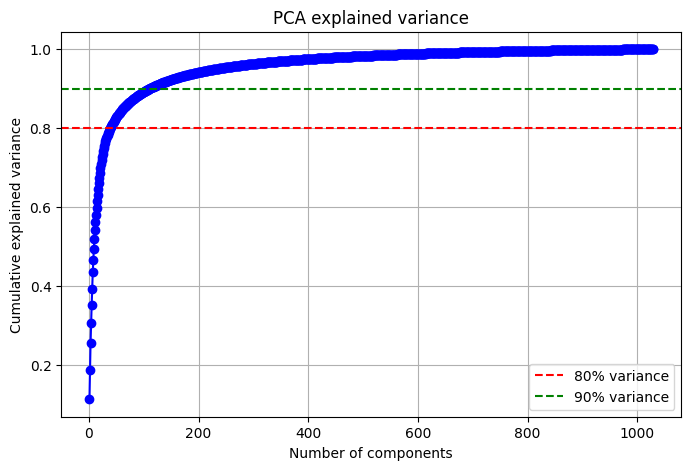

Selected 30 components explaining 0.767 variance


In [203]:

pca_full = PCA(random_state=42)
pca_full.fit(X_pm_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative, 'bo-')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% variance')
plt.axhline(y=0.9, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA explained variance')
plt.legend()
plt.grid(True)
plt.show()

n_comp = 30
print(f"Selected {n_comp} components explaining {cumulative[n_comp-1]:.3f} variance")

In [204]:
# Scaling and PCA for gene-level embeddings

X_gene = gene_feature_df[feature_cols_pm].copy()

gene_scaler = StandardScaler()
X_gene_scaled = gene_scaler.fit_transform(X_gene)

n_components = min(30, X_gene_scaled.shape[0] - 1, X_gene_scaled.shape[1])

gene_pca = PCA(n_components=n_components, random_state=42)
X_gene_pca = gene_pca.fit_transform(X_gene_scaled)

print("Gene-level PCA shape:", X_gene_pca.shape)
print("Explained variance ratio:", gene_pca.explained_variance_ratio_.sum().round(3))

Gene-level PCA shape: (2084, 30)
Explained variance ratio: 0.834


In [205]:
# gene_cluster_metrics = []

# max_k = min(10, X_gene_pca.shape[0])

# for k in range(3, max_k):
#     km = KMeans(
#         n_clusters=k,
#         random_state=42,
#         n_init=30
#     )
#     labels = km.fit_predict(X_gene_pca)

#     gene_cluster_metrics.append({
#         "k": k,
#         "silhouette": silhouette_score(X_gene_pca, labels),
#         "calinski_harabasz": calinski_harabasz_score(X_gene_pca, labels),
#         "davies_bouldin": davies_bouldin_score(X_gene_pca, labels)
#     })

# gene_metrics_df = pd.DataFrame(gene_cluster_metrics)
# gene_metrics_df

In [206]:
# GENE_K = 7

# gene_kmeans = KMeans(
#     n_clusters=GENE_K,
#     random_state=42,
#     n_init=50
# )

# gene_meta_df["gene_cluster"] = gene_kmeans.fit_predict(X_gene_pca)

# gene_meta_df["gene_cluster"].value_counts().sort_index()

## Main hypothesis

If plasma membrane-associated proteins are heterogeneous in their image-derived localization patterns, then their embeddings may contain reproducible substructure rather than behaving as a single homogeneous group.

In [207]:
pca = PCA(n_components=30, random_state=42)
X_pm_pca = pca.fit_transform(X_pm_scaled)

print(X_pm_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

(13049, 30)
Explained variance ratio sum: 0.7665709076461777


## 5. Restricting the analysis to plasma membrane-associated proteins

The main question of this project is whether plasma membrane-associated protein observations contain reproducible latent structure within the broader plasma membrane annotation category. To test this, I subset the merged dataset to observations with `target_pm == 1` and then perform unsupervised analysis within this plasma membrane-enriched subset.

The PCA projection suggests partial separation of several regions in the embedding space. This motivates clustering as an exploratory analysis, but does not by itself prove the existence of discrete biological states.

## Initial cluster interpretation with localization annotations

To interpret the latent clusters, I use the available annotation and metadata columns, including:

- `locations`
- `genes`
- `gene_name`
- `cell_line`
- `antibody`

These metadata allow me to examine whether the clusters correspond to recognizable localization patterns and whether they may be affected by technical structure such as cell line or antibody composition.

## 6. Feature standardization, PCA, and initial clustering

The embedding features are first standardized because clustering is sensitive to scale.

I then apply PCA to reduce dimensionality while preserving the dominant structure of the embedding space. This helps denoise the data and makes clustering more stable.

An initial KMeans solution is used only as an exploratory view. The final number of clusters is selected later using clustering diagnostics and stability analysis.

In [208]:


numeric_cols = pm_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_pm = [c for c in numeric_cols if c != "target_pm"]

X_pm = pm_df[feature_cols_pm].copy()


scaler = StandardScaler()
X_pm_scaled = scaler.fit_transform(X_pm)

pca = PCA(n_components=30, random_state=42)
X_pm_pca = pca.fit_transform(X_pm_scaled)

print("PCA shape:", X_pm_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum().round(3))

PCA shape: (13049, 30)
Explained variance: 0.767


The final number of clusters is not selected from the initial exploratory solution.  
Several values of `k` are compared using complementary clustering diagnostics to identify a solution that balances separation, compactness, stability, and interpretability.

## 8. Choosing the number of clusters

An initial clustering is not enough; the number of clusters must be evaluated more systematically.

To do this, I compare several values of `k` using three complementary metrics:

- **Silhouette score**: higher is better  
- **Calinski-Harabasz score**: higher is better  
- **Davies-Bouldin score**: lower is better

The aim is not to blindly optimise a single metric, but to choose a solution that is both quantitatively sound and biologically interpretable.

In [209]:
cluster_metrics = []

for k in range(4, 9):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels = km.fit_predict(X_pm_pca)

    cluster_metrics.append({
        "k": k,
        "silhouette": silhouette_score(X_pm_pca, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pm_pca, labels),
        "davies_bouldin": davies_bouldin_score(X_pm_pca, labels)
    })

metrics_df = pd.DataFrame(cluster_metrics).sort_values("k")
metrics_df

,k,silhouette,calinski_harabasz,davies_bouldin
0,4,0.098517,1107.965678,2.588780
1,5,0.105441,1023.042740,2.411148
2,6,0.111997,970.307237,2.256098
3,7,0.119639,922.663516,2.055952
4,8,0.088145,881.137373,2.152150


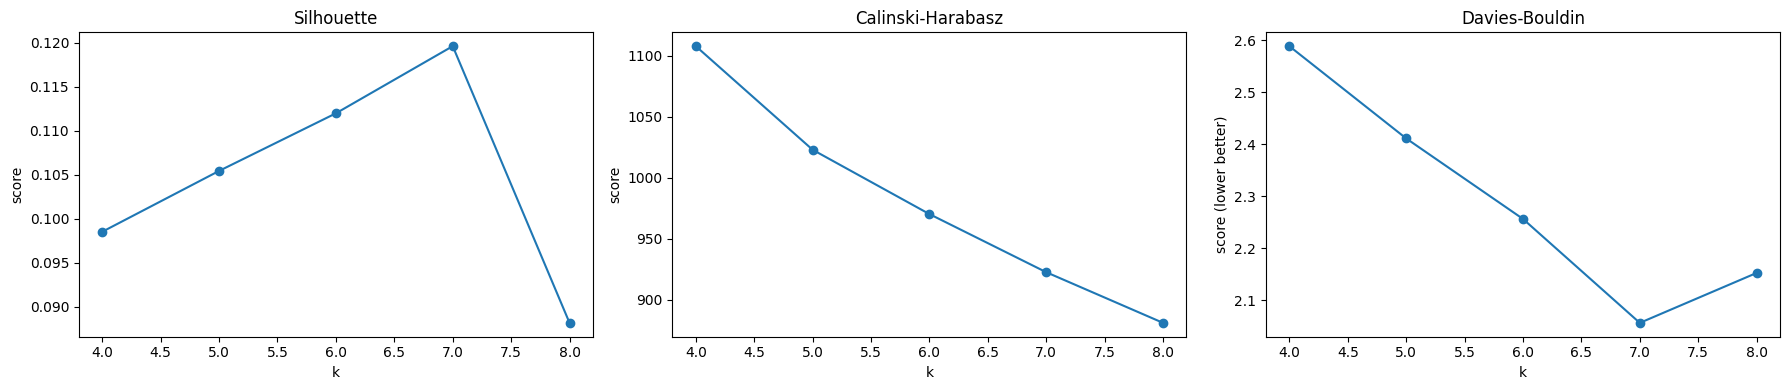

In [210]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(metrics_df["k"], metrics_df["silhouette"], marker="o")
axes[0].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("score")

axes[1].plot(metrics_df["k"], metrics_df["calinski_harabasz"], marker="o")
axes[1].set_title("Calinski-Harabasz")
axes[1].set_xlabel("k")
axes[1].set_ylabel("score")

axes[2].plot(metrics_df["k"], metrics_df["davies_bouldin"], marker="o")
axes[2].set_title("Davies-Bouldin")
axes[2].set_xlabel("k")
axes[2].set_ylabel("score (lower better)")

plt.tight_layout()
plt.show()

In [211]:
best_k_sil = metrics_df.sort_values("silhouette", ascending=False).iloc[0]["k"]
best_k_sil = int(best_k_sil)
best_k_sil

7

The diagnostic metrics support k = 7 as the final observation‑level clustering solution. This value yields the highest silhouette score among the tested values and the lowest Davies‑Bouldin score, while the Calinski‑Harabasz index decreases gradually with increasing k, as expected for a finer partition.
Thus, k = 7 was chosen not as an arbitrary biological assumption, but as a compromise between quantitative separation and interpretability. The moderate silhouette score (≈0.12) indicates that plasma‑membrane‑associated proteins do not form sharply separated groups; rather, the embedding space contains partially overlapping localisation regimes.

In [212]:
kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=20)
pm_df["cluster"] = kmeans.fit_predict(X_pm_pca)

pm_df["cluster"].value_counts().sort_index()

cluster
0    1338
1    3757
2    2231
3     535
4    4479
5     592
6     117
Name: count, dtype: int64

In [213]:
gene_cluster_df = (
    pm_df
    .groupby("genes")["cluster"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"cluster": "gene_major_cluster"})
)

gene_cluster_confidence = (
    pm_df
    .groupby("genes")["cluster"]
    .agg(lambda x: x.value_counts(normalize=True).max())
    .reset_index()
    .rename(columns={"cluster": "major_cluster_fraction"})
)

gene_meta_df = (
    pm_df
    .groupby("genes")
    .agg(
        n_observations=("genes", "size"),
        n_cell_lines=("cell_line", pd.Series.nunique),
        n_antibodies=("antibody", pd.Series.nunique),
        locations=("locations", lambda x: x.dropna().astype(str).mode().iloc[0] if len(x.dropna()) else np.nan),
        gene_name=("gene_name", lambda x: x.dropna().astype(str).mode().iloc[0] if len(x.dropna()) else np.nan),
    )
    .reset_index()
)

gene_df = (
    gene_cluster_df
    .merge(gene_cluster_confidence, on="genes", how="left")
    .merge(gene_meta_df, on="genes", how="left")
)

gene_df.head()

,genes,gene_major_cluster,major_cluster_fraction,n_observations,n_cell_lines,n_antibodies,locations,gene_name
0,AADAT,1,1.000000,6,3,1,Plasma membrane,AADAT
1,AAK1,4,0.916667,12,4,2,"Cytosol,Plasma membrane",AAK1
2,AAMP,0,0.583333,12,4,2,Microtubules,AAMP
3,ABCA1,0,0.500000,6,3,1,Plasma membrane,ABCA1
4,ABCA12,0,0.500000,6,3,1,"Cytosol,Nucleoli,Plasma membrane,Vesicles",ABCA12


In [214]:
for cluster_id in sorted(gene_df["gene_major_cluster"].unique()):
    genes_in_cluster = (
        gene_df[gene_df["gene_major_cluster"] == cluster_id]
        .sort_values("n_observations", ascending=False)
        [[
            "genes",
            "gene_name",
            "locations",
            "major_cluster_fraction",
            "n_observations",
            "n_cell_lines",
            "n_antibodies",
        ]]
        .head(15)
    )
    
    print(f"\nCluster {cluster_id}")
    display(genes_in_cluster)


Cluster 0


,genes,gene_name,locations,major_cluster_fraction,n_observations,n_cell_lines,n_antibodies
2,AAMP,AAMP,Microtubules,0.583333,12,4,2
243,BRWD1,BRWD1,"Cytosol,Nucleoplasm",0.416667,12,5,2
982,KIAA1328,KIAA1328,"Nuclear speckles,Plasma membrane",0.583333,12,5,2
922,IRAK4,IRAK4,"Cytosol,Microtubules,Nucleoli",1.000000,12,3,2
1045,LMTK2,LMTK2,"Centriolar satellite,Nuclear speckles,Plasma m...",0.500000,12,3,2
1099,MAP7D3,MAP7D3,Centrosome,0.583333,12,4,2
864,HPS3,HPS3,Golgi apparatus,0.500000,12,3,2
818,GPRC5A,GPRC5A,"Plasma membrane,Vesicles",0.500000,12,4,2
766,GCC1,GCC1,Golgi apparatus,0.666667,12,3,2
674,FADS2,FADS2,"Endoplasmic reticulum,Nuclear membrane",0.666667,12,5,2



Cluster 1


,genes,gene_name,locations,major_cluster_fraction,n_observations,n_cell_lines,n_antibodies
608,EGFR,EGFR,Golgi apparatus,0.500000,28,9,7
1168,MSN,MSN,Plasma membrane,1.000000,28,3,5
668,EZR,EZR,Plasma membrane,1.000000,20,3,4
1296,PALM2AKAP2,PALM2AKAP2,Plasma membrane,0.722222,18,3,3
216,BAIAP2L1,BAIAP2L1,Plasma membrane,0.611111,18,3,3
505,CTNNB1,CTNNB1,Plasma membrane,0.833333,18,3,3
1656,SLC16A1,SLC16A1,Plasma membrane,0.875000,16,4,3
1678,SLC31A2,SLC31A2,Plasma membrane,0.571429,14,4,3
359,CD44,CD44,Plasma membrane,0.857143,14,3,3
1878,TMEM101,TMEM101,"Nucleoplasm,Plasma membrane",0.666667,12,4,2



Cluster 2


...

,genes,gene_name,locations,major_cluster_fraction,n_observations,n_cell_lines,n_antibodies
299,CAST,CAST,"Cytosol,Endoplasmic reticulum",0.833333,24,5,4
241,BRAF,BRAF,Vesicles,0.541667,24,5,4
802,GPI,GPI,Cytosol,0.909091,22,5,4
108,ANXA1,ANXA1,"Cytosol,Plasma membrane",0.550000,20,3,4
1360,PHGDH,PHGDH,"Cytosol,Plasma membrane",0.666667,18,5,3
69,AHNAK,AHNAK,"Cytosol,Plasma membrane",0.777778,18,3,3
647,ERBB2,ERBB2,Plasma membrane,0.388889,18,5,4
408,CFLAR,CFLAR,"Cytosol,Nucleoplasm,Plasma membrane",0.833333,18,3,3
1458,PRRC2A,PRRC2A,Cytosol,0.666667,18,5,3
394,CDV3,CDV3,Cytosol,0.833333,18,3,3



Cluster 5


,genes,gene_name,locations,major_cluster_fraction,n_observations,n_cell_lines,n_antibodies
64,AFDN,AFDN,"Cell Junctions,Plasma membrane",0.666667,30,3,5
983,KIAA1522,KIAA1522,"Cell Junctions,Nucleoplasm,Plasma membrane",0.562500,16,5,3
629,EPB41,EPB41,"Cell Junctions,Cytosol,Plasma membrane",0.437500,16,5,3
1608,SCN8A,SCN8A,"Cell Junctions,Plasma membrane",0.428571,14,5,3
1073,LSR,LSR,"Cell Junctions,Plasma membrane",0.583333,12,5,2
1293,PAK4,PAK4,"Cell Junctions,Plasma membrane",0.666667,12,3,2
1865,TJP3,TJP3,"Cell Junctions,Nucleoplasm",0.666667,12,3,2
383,CDH3,CDH3,"Cell Junctions,Plasma membrane",0.500000,12,5,2
1673,SLC2A12,SLC2A12,Plasma membrane,0.300000,10,5,2
1490,PTPRK,PTPRK,Cell Junctions,0.600000,10,3,2



Cluster 6


,genes,gene_name,locations,major_cluster_fraction,n_observations,n_cell_lines,n_antibodies
2083,ZYX,ZYX,Focal adhesion sites,0.928571,14,5,3
621,ENAH,ENAH,"Cytosol,Focal adhesion sites,Plasma membrane",0.750000,12,3,2
1055,LPP,LPP,"Cytosol,Focal adhesion sites",0.666667,12,3,2
2005,VASP,VASP,"Cytosol,Focal adhesion sites,Plasma membrane",0.400000,10,3,2
1849,TES,TES,"Cell Junctions,Cytosol",0.500000,8,2,2
513,CUTA,CUTA,"Focal adhesion sites,Plasma membrane",0.666667,6,3,1
612,EIF2B2,EIF2B2,"Focal adhesion sites,Nucleoplasm,Plasma membrane",0.500000,6,3,1
1523,RASAL2,RASAL2,"Cytosol,Plasma membrane",0.500000,6,3,1
1755,SORBS1,SORBS1,"Centrosome,Focal adhesion sites",0.500000,6,3,1
1882,TMEM139,TMEM139,Focal adhesion sites,0.500000,6,3,1


In [215]:
gene_level_summary = (
    gene_df
    .groupby("gene_major_cluster")
    .agg(
        n_genes=("genes", "size"),
        median_major_cluster_fraction=("major_cluster_fraction", "median"),
        mean_major_cluster_fraction=("major_cluster_fraction", "mean"),
        median_observations=("n_observations", "median"),
        median_cell_lines=("n_cell_lines", "median"),
        median_antibodies=("n_antibodies", "median"),
    )
    .reset_index()
)

gene_level_summary

,gene_major_cluster,n_genes,median_major_cluster_fraction,mean_major_cluster_fraction,median_observations,median_cell_lines,median_antibodies
0,0,211,0.666667,0.681280,6.0,3.0,1.0
1,1,604,0.736111,0.739451,6.0,3.0,1.0
2,2,353,0.666667,0.721498,6.0,3.0,1.0
3,3,78,0.666667,0.715100,6.0,3.0,1.0
4,4,739,0.750000,0.751356,6.0,3.0,1.0
5,5,83,0.500000,0.614601,6.0,3.0,1.0
6,6,16,0.500000,0.614286,6.0,3.0,1.0


## Technical bias check

A key concern in image-derived biological embeddings is that clusters may reflect technical or experimental factors rather than biological structure. In this dataset, possible confounders include the number of observations per gene/protein, the number of cell lines, and the number of antibodies.

I therefore inspect whether the final observation-level clusters and their gene/protein-level summaries are strongly associated with these technical variables. This analysis is not intended to eliminate all possible confounding, but to provide a first diagnostic check.

In [216]:
bias_summary = (
    gene_df
    .groupby("gene_major_cluster")
    .agg(
        n_genes=("genes", "size"),
        median_major_cluster_fraction=("major_cluster_fraction", "median"),
        mean_major_cluster_fraction=("major_cluster_fraction", "mean"),
        median_observations=("n_observations", "median"),
        mean_observations=("n_observations", "mean"),
        median_cell_lines=("n_cell_lines", "median"),
        mean_cell_lines=("n_cell_lines", "mean"),
        median_antibodies=("n_antibodies", "median"),
        mean_antibodies=("n_antibodies", "mean"),
    )
    .reset_index()
)

bias_summary

,gene_major_cluster,n_genes,median_major_cluster_fraction,mean_major_cluster_fraction,median_observations,mean_observations,median_cell_lines,mean_cell_lines,median_antibodies,mean_antibodies
0,0,211,0.666667,0.681280,6.0,5.890995,3.0,2.701422,1.0,1.142180
1,1,604,0.736111,0.739451,6.0,5.692053,3.0,2.559603,1.0,1.168874
2,2,353,0.666667,0.721498,6.0,6.796034,3.0,2.957507,1.0,1.254958
3,3,78,0.666667,0.715100,6.0,6.743590,3.0,2.871795,1.0,1.294872
4,4,739,0.750000,0.751356,6.0,6.529093,3.0,2.813261,1.0,1.246279
5,5,83,0.500000,0.614601,6.0,6.096386,3.0,2.590361,1.0,1.325301
6,6,16,0.500000,0.614286,6.0,7.000000,3.0,2.750000,1.0,1.375000


The technical bias check suggests whether the major clusters are trivially explained by differences in observation count, cell-line coverage, or antibody coverage. If these distributions are broadly similar across clusters, this supports the interpretation that the clustering is not driven only by these simple technical factors. However, this remains a diagnostic analysis rather than definitive proof that all technical effects are absent.

## 9. Bootstrap cluster stability
To assess whether the observed clustering structure is reproducible (rather than a random sampling artefact), a bootstrap‑style procedure was used to evaluate cluster stability.

In each iteration:
1. I sample two overlapping subsets of the data
2. I cluster both subsets independently
3. I compare the cluster assignments on the overlapping observations using Adjusted Rand Index (ARI)

Higher ARI values indicate a more reproducible latent structure.

In [218]:

def bootstrap_cluster_stability(X, k=5, n_boot=12, sample_frac=0.8, random_state=42):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    ari_scores = []

    for i in range(n_boot):
        idx1 = rng.choice(n, size=int(n * sample_frac), replace=False)
        idx2 = rng.choice(n, size=int(n * sample_frac), replace=False)

        overlap = np.intersect1d(idx1, idx2)
        if len(overlap) < 100:
            continue

        km1 = KMeans(n_clusters=k, random_state=100 + i, n_init=20)
        km2 = KMeans(n_clusters=k, random_state=200 + i, n_init=20)

        lab1 = km1.fit_predict(X[idx1])
        lab2 = km2.fit_predict(X[idx2])

        idx1_map = {v: j for j, v in enumerate(idx1)}
        idx2_map = {v: j for j, v in enumerate(idx2)}

        overlap_lab1 = np.array([lab1[idx1_map[o]] for o in overlap])
        overlap_lab2 = np.array([lab2[idx2_map[o]] for o in overlap])

        ari = adjusted_rand_score(overlap_lab1, overlap_lab2)
        ari_scores.append(ari)

    return ari_scores

stability_scores = bootstrap_cluster_stability(
    X_pm_pca,
    k=int(pm_df["cluster"].nunique()),
    n_boot=12,
    sample_frac=0.8,
    random_state=42
)

print("ARI scores:", stability_scores)
print("Mean ARI:", np.mean(stability_scores))
print("Std ARI:", np.std(stability_scores))

ARI scores: [0.925077879967574, 0.9581838770918139, 0.9577416515721918, 0.9609415334757552, 0.5469181675347133, 0.9841585858389003, 0.9770519553547572, 0.9833674758944383, 0.5563581651263052, 0.9481618797545311, 0.9653626227391029, 0.9673143055369466]
Mean ARI: 0.8942198416572525
Std ARI: 0.15397799167595144


The bootstrap stability analysis gives a high mean ARI (0.89), indicating that the clustering structure is largely reproducible under resampling. However, several bootstrap comparisons yield lower ARI values (down to 0.55), showing that some cluster boundaries are less stable. This result is consistent with the modest silhouette score and supports the interpretation of clusters as partially overlapping localisation regimes rather than sharply separated biological classes.

In [219]:
summary_rows = []

for cl in sorted(pm_df["cluster"].unique()):
    sub = pm_df[pm_df["cluster"] == cl].copy()

    top_locations = sub["locations"].fillna("NA").value_counts().head(10).index.tolist()
    top_genes = sub["genes"].value_counts().head(10).index.tolist()
    top_cell_lines = sub["cell_line"].value_counts().head(5).index.tolist()
    top_antibodies = sub["antibody"].value_counts().head(5).index.tolist()

    summary_rows.append({
        "cluster": cl,
        "n_rows": len(sub),
        "n_genes": sub["genes"].nunique(),
        "top_locations": "; ".join(map(str, top_locations)),
        "top_cell_lines": "; ".join(map(str, top_cell_lines)),
        "top_antibodies": "; ".join(map(str, top_antibodies)),
        "top_genes": "; ".join(map(str, top_genes)),
    })

cluster_summary_df = pd.DataFrame(summary_rows).sort_values("cluster")
cluster_summary_df

,cluster,n_rows,n_genes,top_locations,top_cell_lines,top_antibodies,top_genes
0,0,1338,525,"Vesicles; Golgi apparatus; Golgi apparatus,Pla...",U2OS; A-431; U-251MG; SiHa; Rh30,HPA002017; HPA010657; HPA011165; CAB016685; HP...,IRAK4; EGFR; CLTA; SIRT2; RRP12; BRAF; FADS2; ...
1,1,3757,1307,"Plasma membrane; Cytosol,Plasma membrane; Nucl...",U2OS; A-431; U-251MG; HeLa; HEL,CAB000316; HPA001231; HPA001330; HPA001580; HP...,MSN; EZR; CTNNB1; EGFR; SLC16A1; PALM2AKAP2; C...
2,2,2231,665,"Nucleoplasm,Plasma membrane; Nucleoplasm; Cyto...",U2OS; U-251MG; A-431; PC-3; HeLa,HPA000390; HPA000886; HPA000909; HPA000913; HP...,ACSS2; CEBPE; POGZ; DLL3; KLHL7; DNAJC9; INTS1...
3,3,535,182,"Actin filaments,Plasma membrane; Actin filamen...",U2OS; A-431; U-251MG; BJ [Human fibroblast]; Rh30,CAB000356; HPA000368; HPA001115; HPA001644; HP...,FLNA; LUZP1; SEPTIN2; MYH9; CALD1; PPP1R12A; C...
4,4,4479,1237,"Cytosol,Plasma membrane; Plasma membrane; Cyto...",U2OS; U-251MG; A-431; PC-3; MCF-7,HPA000962; HPA001308; HPA001399; HPA001478; HP...,CAST; GPI; HSPB1; GAPVD1; ARHGEF1; FSCN1; CFLA...
5,5,592,268,"Plasma membrane; Cell Junctions,Plasma membran...",A-431; MCF-7; U2OS; CACO-2; RT-4,CAB009228; HPA030212; HPA030443; HPA049868; HP...,AFDN; KIAA1522; TJP3; ARVCF; PAK4; LSR; EPB41;...
6,6,117,49,"Cytosol,Focal adhesion sites,Plasma membrane; ...",U2OS; U-251MG; A-431; SiHa; RT-4,HPA004835; HPA017342; HPA028696; HPA073497; HP...,ZYX; ENAH; LPP; VASP; LASP1; TES; CUTA; RAPGEF...


These gene lists form one of the main reusable outputs of the project. They can later be used for GO enrichment, literature review, and communication with potential PhD supervisors.

## GO enrichment and membrane-mechanics signatures

To strengthen the biological interpretation of the clusters, I perform two complementary analyses:

1. **GO enrichment analysis** for each cluster  
   This tests whether cluster gene sets are enriched in processes related to focal adhesion, actin cytoskeleton, endocytosis, tight junctions, and receptor signaling.

2. **Targeted membrane-mechanics signature analysis**  
   This tests whether clusters are enriched in manually curated protein groups associated with:
   - cortical membrane organization
   - focal adhesion / motility
   - contractility
   - curvature / tension sensitivity
   - caveolae
   - ezrin/moesin cortical coupling
   - BAR-domain proteins
   - endocytic adaptors
   - integrin pathway

This does not directly measure membrane dynamics. It only tests whether some clusters are enriched for proteins whose known functions are consistent with membrane organization, adhesion, curvature, trafficking, or cortical coupling.

In [220]:
# Prepare one clean gene list per cluster

cluster_gene_sets = {
    cl: sorted(
        gene_df.loc[gene_df["gene_major_cluster"] == cl, "genes"]
        .dropna()
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )
    for cl in sorted(gene_df["gene_major_cluster"].dropna().unique())
}

for cl, genes in cluster_gene_sets.items():
    print(f"Cluster {cl}: {len(genes)} genes")
    print(genes[:15], "\n")

Cluster 0: 211 genes
['AAMP', 'ABCA1', 'ABCA12', 'ABCB6', 'ABCC4', 'ACP4', 'ADCY4', 'ADCY5', 'AGRN', 'AGTPBP1', 'AJM1', 'AKAP5', 'AKTIP', 'AMER1', 'APOBR'] 

Cluster 1: 604 genes
['AADAT', 'ABCC3', 'ABCC6', 'ABCG2', 'ABI1', 'ACKR3', 'ADAM12', 'ADAMTS2', 'ADCY7', 'ADD1', 'ADD3', 'ADGRA2', 'ADH7', 'ADORA1', 'ADPRHL1'] 

Cluster 2: 353 genes
['ABCB11', 'ABCB4', 'ABCC9', 'ABHD3', 'ACOT9', 'ACSS2', 'ACTL10', 'ACTR10', 'ADCY3', 'ADCY8', 'ADD2', 'ADK', 'ADRM1', 'ANKFN1', 'ANKRD42'] 

Cluster 3: 78 genes
['ADAM23', 'APPL1', 'ARHGAP21', 'ARHGAP33', 'ARL13A', 'ATP6V1H', 'AVEN', 'AXL', 'BZW2', 'C11ORF42', 'CALD1', 'CCDC69', 'CD274', 'CDC42EP1', 'CDC42EP3'] 

Cluster 4: 739 genes
['AAK1', 'ABCA7', 'ABCB1', 'ABCC1', 'ACTR6', 'ADA', 'ADAM10', 'ADAM28', 'ADAM33', 'ADAMTS1', 'ADAMTSL4', 'ADAP1', 'ADCK5', 'ADCY9', 'ADGRB2'] 

Cluster 5: 83 genes
['ABCC5', 'ACTN1', 'ADGRL2', 'AFDN', 'AFM', 'AGER', 'ARVCF', 'ATP1A1', 'C2CD2L', 'CACNA1I', 'CADM1', 'CAVIN3', 'CCDC66', 'CD34', 'CD9'] 

Cluster 6: 16 genes
[

In [221]:
pip install gprofiler-official

Python(9263) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [222]:


gp = GProfiler(return_dataframe=True)

go_results = []

for cl, genes in cluster_gene_sets.items():
    if len(genes) < 5:
        continue

    res = gp.profile(
        organism="hsapiens",
        query=genes,
        sources=["GO:BP", "GO:CC"],
        user_threshold=0.05
    )

    if res is None or len(res) == 0:
        continue

    res = res.copy()
    res["cluster"] = cl
    go_results.append(res)

if len(go_results) > 0:
    go_df = pd.concat(go_results, ignore_index=True)
else:
    go_df = pd.DataFrame()

print("GO results shape:", go_df.shape)
go_df.head()

GO results shape: (1206, 15)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:CC,GO:0005886,plasma membrane,5.292294e-42,True,"""The membrane surrounding a cell that separate...",5906,204,150,22155,0.735294,0.025398,query_1,"[GO:0016020, GO:0071944]",0
1,GO:CC,GO:0071944,cell periphery,2.880734e-41,True,"""The broad region around and including the pla...",6263,204,153,22155,0.750000,0.024429,query_1,[GO:0110165],0
2,GO:CC,GO:0016020,membrane,9.055031e-30,True,"""A lipid bilayer along with all the proteins a...",9975,204,173,22155,0.848039,0.017343,query_1,[GO:0110165],0
3,GO:CC,GO:0120025,plasma membrane bounded cell projection,6.973954e-09,True,"""A prolongation or process extending from a ce...",2449,204,57,22155,0.279412,0.023275,query_1,[GO:0042995],0
4,GO:CC,GO:0042995,cell projection,1.414446e-08,True,"""A prolongation or process extending from a ce...",2566,204,58,22155,0.284314,0.022603,query_1,[GO:0110165],0


In [239]:

top_go_per_cluster = go_df.sort_values(["cluster", "p_value"]).groupby("cluster").head(5)
display(top_go_per_cluster[["cluster", "source", "name", "p_value", "intersection_size"]])

,cluster,source,name,p_value,intersection_size
0,0,GO:CC,plasma membrane,5.292294e-42,150
1,0,GO:CC,cell periphery,2.880734e-41,153
2,0,GO:CC,membrane,9.055031e-30,173
3,0,GO:CC,plasma membrane bounded cell projection,6.973954e-09,57
4,0,GO:CC,cell projection,1.414446e-08,58
95,1,GO:CC,cell periphery,6.911040e-109,420
96,1,GO:CC,plasma membrane,1.658347e-105,405
97,1,GO:CC,membrane,2.398364e-71,470
98,1,GO:CC,plasma membrane region,1.683613e-43,136
99,1,GO:CC,cell junction,2.561214e-43,186


In [223]:
# Keep only terms related to the biological themes of interest

keywords = [
    "focal adhesion",
    "cell-substrate junction",
    "actin cytoskeleton",
    "actin filament",
    "endocytosis",
    "endocytic",
    "tight junction",
    "cell junction",
    "adherens junction",
    "receptor signaling",
    "transmembrane receptor",
    "signal transduction",
    "cortical actin",
    "membrane raft",
    "caveola",
    "integrin",
    "lamellipodium",
    "cell migration",
    "cytoskeleton organization",
    "contractile",
    "actomyosin"
]

if len(go_df) > 0:
    mask = go_df["name"].str.lower().apply(
        lambda x: any(k in x for k in keywords)
    )
    go_focus_df = go_df.loc[mask].copy()
    go_focus_df = go_focus_df.sort_values(["cluster", "p_value", "source"])
else:
    go_focus_df = pd.DataFrame()

go_focus_df[[
    "cluster", "source", "name", "p_value", "term_size",
    "query_size", "intersection_size", "effective_domain_size"
]].head(50)

,cluster,source,name,p_value,term_size,query_size,intersection_size,effective_domain_size
15,0,GO:BP,cell surface receptor signaling pathway,7.009528e-06,2834,192,57,20972
26,0,GO:BP,signal transduction,1.802802e-04,6063,192,90,20972
28,0,GO:BP,regulation of signal transduction,2.035300e-04,3031,192,56,20972
52,0,GO:BP,positive regulation of signal transduction,4.086145e-03,1569,192,34,20972
81,0,GO:BP,brain-derived neurotrophic factor receptor sig...,2.577712e-02,57,192,6,20972
84,0,GO:CC,membrane raft,2.674056e-02,289,204,11,22155
91,0,GO:BP,endocytosis,4.234550e-02,694,192,19,20972
99,1,GO:CC,cell junction,2.561214e-43,2370,578,186,22155
113,1,GO:BP,signal transduction,2.123493e-22,6063,549,274,20972
115,1,GO:CC,cell-cell junction,6.305764e-22,522,578,63,22155


In [224]:
# Show the most relevant GO terms per cluster

if len(go_focus_df) > 0:
    for cl in sorted(go_focus_df["cluster"].unique()):
        print("=" * 100)
        print(f"CLUSTER {cl}")
        display(
            go_focus_df.loc[go_focus_df["cluster"] == cl, [
                "source", "name", "p_value", "intersection_size", "term_size"
            ]].head(15)
        )
else:
    print("No focused GO terms found with the current keyword filter.")

CLUSTER 0


,source,name,p_value,intersection_size,term_size
15,GO:BP,cell surface receptor signaling pathway,0.000007,57,2834
26,GO:BP,signal transduction,0.000180,90,6063
28,GO:BP,regulation of signal transduction,0.000204,56,3031
52,GO:BP,positive regulation of signal transduction,0.004086,34,1569
81,GO:BP,brain-derived neurotrophic factor receptor sig...,0.025777,6,57
84,GO:CC,membrane raft,0.026741,11,289
91,GO:BP,endocytosis,0.042345,19,694


CLUSTER 1


,source,name,p_value,intersection_size,term_size
99,GO:CC,cell junction,2.561214e-43,186,2370
113,GO:BP,signal transduction,2.123493e-22,274,6063
115,GO:CC,cell-cell junction,6.305764e-22,63,522
118,GO:BP,cell migration,7.449977e-20,111,1532
131,GO:CC,cell-substrate junction,1.283259e-17,52,435
133,GO:CC,focal adhesion,2.529770e-17,51,425
134,GO:BP,actin cytoskeleton organization,5.947621e-17,68,716
137,GO:BP,actin filament-based process,2.668443e-16,72,816
144,GO:CC,membrane raft,1.805223e-15,40,289
155,GO:BP,regulation of signal transduction,5.271767e-14,155,3031


CLUSTER 2


...

,source,name,p_value,intersection_size,term_size
737,GO:BP,signal transduction,5.958329e-27,333,6063
743,GO:CC,cell junction,1.317638e-22,171,2370
746,GO:BP,cell surface receptor signaling pathway,2.455313e-18,183,2834
768,GO:BP,intracellular signal transduction,5.693138e-13,174,2963
769,GO:BP,cell migration,6.039842e-13,111,1532
771,GO:BP,actin filament-based process,1.345373e-12,74,816
774,GO:BP,actin cytoskeleton organization,7.800121e-12,67,716
782,GO:BP,regulation of signal transduction,4.788140e-11,171,3031
784,GO:BP,cytoskeleton organization,1.851291e-10,105,1534
785,GO:BP,endocytosis,2.200386e-10,63,694


CLUSTER 5


,source,name,p_value,intersection_size,term_size
1113,GO:CC,cell-cell junction,1.607756e-21,27,522
1114,GO:CC,cell junction,1.891614e-21,46,2370
1117,GO:BP,cell-cell junction organization,9.276110e-15,17,216
1121,GO:CC,tight junction,3.854450e-11,12,140
1122,GO:CC,adherens junction,6.029681e-11,13,189
1124,GO:CC,bicellular tight junction,6.863006e-10,11,134
1125,GO:BP,cell-cell junction assembly,1.457480e-09,12,157
1126,GO:BP,cell junction organization,5.503189e-09,21,829
1133,GO:BP,cell migration,4.270966e-07,25,1532
1135,GO:BP,cell junction assembly,1.404638e-06,15,509


CLUSTER 6


,source,name,p_value,intersection_size,term_size
1197,GO:CC,focal adhesion,2.569565e-08,8,425
1198,GO:CC,cell-substrate junction,3.089664e-08,8,435
1201,GO:CC,contractile actin filament bundle,4.282204e-05,4,83
1202,GO:CC,actomyosin,5.936287e-05,4,90
1203,GO:CC,actin filament bundle,6.206524e-05,4,91
1204,GO:CC,cell junction,1.116278e-04,10,2370
1205,GO:CC,actin cytoskeleton,3.822490e-03,5,537


In [225]:
import re

theme_map = {
    "focal_adhesion": [
        "focal adhesion", "cell-substrate junction", "integrin"
    ],
    "actin_cytoskeleton": [
        "actin cytoskeleton", "actin filament", "cortical actin", "actomyosin", "contractile"
    ],
    "endocytosis": [
        "endocytosis", "endocytic"
    ],
    "tight_junction": [
        "tight junction", "cell junction", "adherens junction"
    ],
    "receptor_signaling": [
        "receptor signaling", "transmembrane receptor", "signal transduction"
    ],
    "migration_motility": [
        "cell migration", "lamellipodium"
    ],
    "caveola_rafts": [
        "caveola", "membrane raft"
    ]
}

theme_rows = []

if len(go_df) > 0:
    for cl in sorted(go_df["cluster"].unique()):
        sub = go_df[go_df["cluster"] == cl].copy()
        names = sub["name"].fillna("").str.lower()

        row = {"cluster": cl}
        for theme, pats in theme_map.items():
            matched = sub[names.apply(lambda x: any(p in x for p in pats))]
            if len(matched) == 0:
                row[theme] = 0.0
            else:
                # stronger significance -> higher score
                row[theme] = (-np.log10(matched["p_value"].clip(lower=1e-300))).max()
        theme_rows.append(row)

go_theme_df = pd.DataFrame(theme_rows).set_index("cluster")
go_theme_df

,focal_adhesion,actin_cytoskeleton,endocytosis,tight_junction,receptor_signaling,migration_motility,caveola_rafts
cluster,,,,,,,
0,0.000000,0.000000,1.373193,0.000000,5.154311,0.000000,1.572829
1,16.891686,16.225657,6.552137,42.591554,21.672949,19.127845,14.743469
2,0.000000,2.058880,0.000000,5.223655,4.875163,0.000000,0.000000
3,4.211251,30.138238,0.000000,9.315816,0.000000,0.000000,0.000000
4,8.702058,11.871157,9.657501,21.880204,26.224876,12.218974,5.168544
5,2.129053,3.936605,0.000000,20.793780,0.000000,6.369474,0.000000
6,7.590140,4.368333,0.000000,3.952228,0.000000,0.000000,0.000000


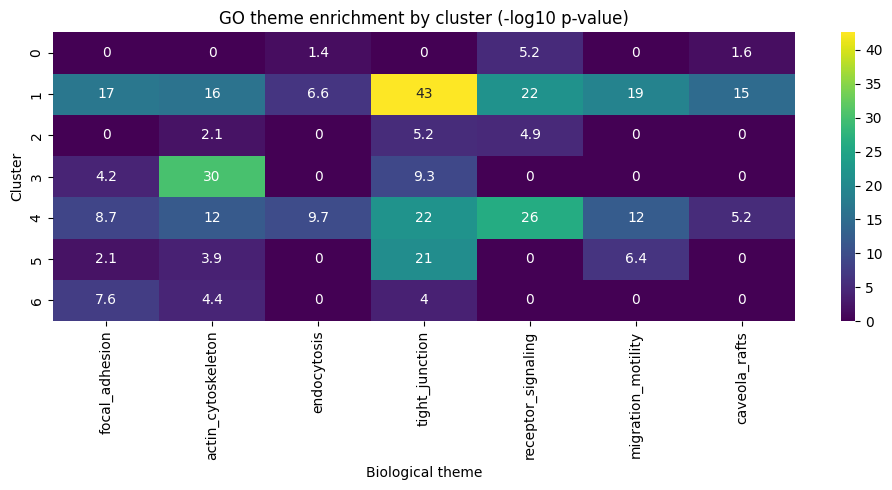

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(go_theme_df, annot=True, cmap="viridis")
plt.title("GO theme enrichment by cluster (-log10 p-value)")
plt.xlabel("Biological theme")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## Targeted membrane-mechanics signatures

BecBecause static image embeddings cannot directly measure membrane dynamics, I test a weaker but biologically interpretable question:

Do some clusters show enrichment for proteins associated with membrane organization, adhesion, curvature, trafficking, or cortical coupling

The curated signatures include:
- cortical membrane coupling
- focal adhesion / migration
- contractility
- curvature / tension sensitivity
- caveolae
- ezrin/moesin module
- BAR-domain proteins
- endocytic adaptors
- integrin pathway

In [227]:
mechanical_signatures = {
    "cortical_membrane": {
        "EZR", "RDX", "MSN", "SCRIB", "EPB41L2", "EPB41L5", "MPP5", "CDC42", "IQGAP1"
    },
    "focal_adhesion_motility": {
        "TLN1", "TLN2", "VASP", "ZYX", "PXN", "BCAR1", "ENAH", "LASP1", "PTK2", "PTK2B", "ACTN1", "ACTN4"
    },
    "contractile_cortex": {
        "MYH9", "MYH10", "MYL9", "CALD1", "FLNA", "FLNB", "SEPTIN2", "SEPTIN7", "ROCK1", "ROCK2", "ACTB"
    },
    "curvature_tension_sensitive": {
        "CAV1", "CAV2", "CAVIN1", "CAVIN2", "PACSIN2", "EZR", "MSN", "RDX", "AMPH", "SNX9", "SNX18"
    },
    "caveolae": {
        "CAV1", "CAV2", "CAVIN1", "CAVIN2", "CAVIN3", "EHD2"
    },
    "ezrin_moesin_module": {
        "EZR", "MSN", "RDX", "SLC9A3R1", "SLC9A3R2"
    },
    "bar_domain_proteins": {
        "AMPH", "BIN1", "SH3GL1", "SH3GL2", "SH3GL3", "SNX9", "SNX18", "PACSIN1", "PACSIN2", "PACSIN3"
    },
    "endocytic_adaptors": {
        "CLTA", "CLTC", "AP2A1", "AP2A2", "AP2B1", "AP2M1", "EPS15", "ITSN1", "ITSN2", "AAK1", "DAB2", "FCHO1", "FCHO2"
    },
    "integrin_pathway": {
        "ITGA2", "ITGA3", "ITGA5", "ITGA6", "ITGAV", "ITGB1", "ITGB4", "PXN", "TLN1", "VCL", "BCAR1", "PTK2"
    }
}

for k, v in mechanical_signatures.items():
    print(k, len(v), sorted(list(v))[:10])

cortical_membrane 9 ['CDC42', 'EPB41L2', 'EPB41L5', 'EZR', 'IQGAP1', 'MPP5', 'MSN', 'RDX', 'SCRIB']
focal_adhesion_motility 12 ['ACTN1', 'ACTN4', 'BCAR1', 'ENAH', 'LASP1', 'PTK2', 'PTK2B', 'PXN', 'TLN1', 'TLN2']
contractile_cortex 11 ['ACTB', 'CALD1', 'FLNA', 'FLNB', 'MYH10', 'MYH9', 'MYL9', 'ROCK1', 'ROCK2', 'SEPTIN2']
curvature_tension_sensitive 11 ['AMPH', 'CAV1', 'CAV2', 'CAVIN1', 'CAVIN2', 'EZR', 'MSN', 'PACSIN2', 'RDX', 'SNX18']
caveolae 6 ['CAV1', 'CAV2', 'CAVIN1', 'CAVIN2', 'CAVIN3', 'EHD2']
ezrin_moesin_module 5 ['EZR', 'MSN', 'RDX', 'SLC9A3R1', 'SLC9A3R2']
bar_domain_proteins 10 ['AMPH', 'BIN1', 'PACSIN1', 'PACSIN2', 'PACSIN3', 'SH3GL1', 'SH3GL2', 'SH3GL3', 'SNX18', 'SNX9']
endocytic_adaptors 13 ['AAK1', 'AP2A1', 'AP2A2', 'AP2B1', 'AP2M1', 'CLTA', 'CLTC', 'DAB2', 'EPS15', 'FCHO1']
integrin_pathway 12 ['BCAR1', 'ITGA2', 'ITGA3', 'ITGA5', 'ITGA6', 'ITGAV', 'ITGB1', 'ITGB4', 'PTK2', 'PXN']


In [228]:
from scipy.stats import fisher_exact

# universe = all PM genes that entered the gene-level cluster analysis
background_genes = set(
    gene_df["genes"].dropna().astype(str).str.upper().unique().tolist()
)

cluster_gene_sets_upper = {
    cl: set(genes)
    for cl, genes in cluster_gene_sets.items()
}

def bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)

    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.minimum(adj, 1.0)
    return out

rows = []

for cl, cluster_genes in cluster_gene_sets_upper.items():
    not_cluster_genes = background_genes - cluster_genes

    for sig_name, sig_genes_raw in mechanical_signatures.items():
        sig_genes = set(sig_genes_raw) & background_genes

        a = len(cluster_genes & sig_genes)
        b = len(cluster_genes - sig_genes)
        c = len(not_cluster_genes & sig_genes)
        d = len(not_cluster_genes - sig_genes)

        table = [[a, b], [c, d]]
        odds_ratio, pvalue = fisher_exact(table, alternative="greater")

        rows.append({
            "cluster": cl,
            "signature": sig_name,
            "overlap_genes": a,
            "cluster_size": len(cluster_genes),
            "signature_size_in_background": len(sig_genes),
            "odds_ratio": odds_ratio,
            "p_value": pvalue,
            "matched_genes": ", ".join(sorted(cluster_genes & sig_genes))
        })

signature_enrichment_df = pd.DataFrame(rows)
signature_enrichment_df["p_adj_bh"] = bh_adjust(signature_enrichment_df["p_value"].values)

signature_enrichment_df = signature_enrichment_df.sort_values(
    ["cluster", "p_adj_bh", "odds_ratio"],
    ascending=[True, True, False]
)

signature_enrichment_df.head(30)

,cluster,signature,overlap_genes,cluster_size,signature_size_in_background,odds_ratio,p_value,matched_genes,p_adj_bh
7,0,endocytic_adaptors,1,211,6,1.779048,4.733919e-01,CLTA,1.000000
0,0,cortical_membrane,0,211,7,0.000000,1.000000e+00,,1.000000
1,0,focal_adhesion_motility,0,211,8,0.000000,1.000000e+00,,1.000000
2,0,contractile_cortex,0,211,5,0.000000,1.000000e+00,,1.000000
3,0,curvature_tension_sensitive,0,211,8,0.000000,1.000000e+00,,1.000000
4,0,caveolae,0,211,3,0.000000,1.000000e+00,,1.000000
5,0,ezrin_moesin_module,0,211,5,0.000000,1.000000e+00,,1.000000
6,0,bar_domain_proteins,0,211,4,0.000000,1.000000e+00,,1.000000
8,0,integrin_pathway,0,211,5,0.000000,1.000000e+00,,1.000000
14,1,ezrin_moesin_module,5,604,5,inf,2.021033e-03,"EZR, MSN, RDX, SLC9A3R1, SLC9A3R2",0.042442


In [229]:
sig_hits = signature_enrichment_df[
    (signature_enrichment_df["overlap_genes"] >= 2) &
    (signature_enrichment_df["p_adj_bh"] < 0.1)
].copy()

sig_hits[[
    "cluster", "signature", "overlap_genes",
    "odds_ratio", "p_value", "p_adj_bh", "matched_genes"
]].sort_values(["cluster", "p_adj_bh", "odds_ratio"], ascending=[True, True, False])

,cluster,signature,overlap_genes,odds_ratio,p_value,p_adj_bh,matched_genes
14,1,ezrin_moesin_module,5,inf,2.021033e-03,0.042442,"EZR, MSN, RDX, SLC9A3R1, SLC9A3R2"
9,1,cortical_membrane,6,14.839465,3.070658e-03,0.048363,"EPB41L2, EPB41L5, EZR, MSN, RDX, SCRIB"
29,3,contractile_cortex,5,inf,6.475731e-08,0.000004,"CALD1, FLNA, FLNB, MYH9, SEPTIN2"
55,6,focal_adhesion_motility,3,95.215385,2.033576e-05,0.000641,"ENAH, VASP, ZYX"


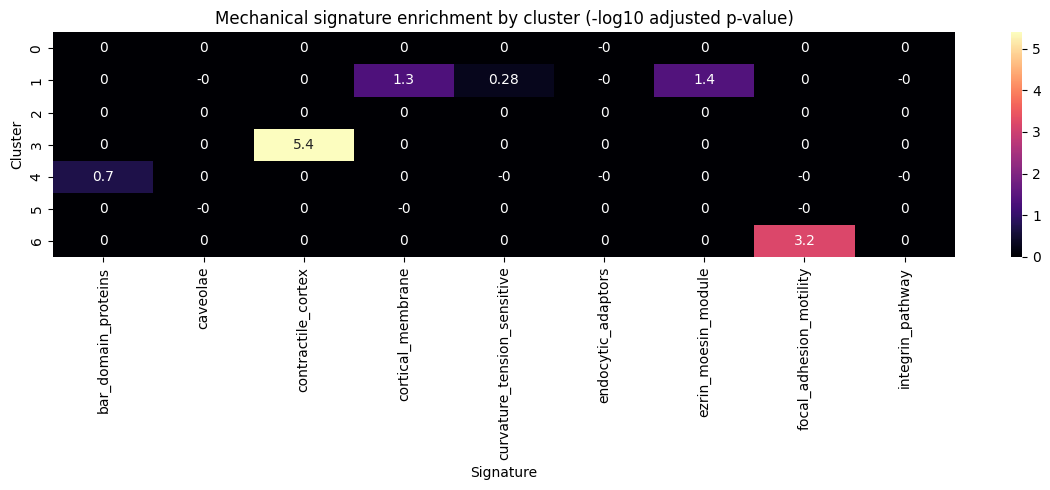

In [230]:
sig_plot_df = signature_enrichment_df.copy()
sig_plot_df["score"] = -np.log10(sig_plot_df["p_adj_bh"].clip(lower=1e-300))
sig_plot_df.loc[sig_plot_df["overlap_genes"] < 1, "score"] = 0.0

sig_heatmap = sig_plot_df.pivot(
    index="cluster",
    columns="signature",
    values="score"
).fillna(0)

plt.figure(figsize=(12, 5))
sns.heatmap(sig_heatmap, annot=True, cmap="magma")
plt.title("Mechanical signature enrichment by cluster (-log10 adjusted p-value)")
plt.xlabel("Signature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [231]:
for cl in sorted(signature_enrichment_df["cluster"].unique()):
    sub = signature_enrichment_df[signature_enrichment_df["cluster"] == cl].copy()
    sub = sub.sort_values(["p_adj_bh", "odds_ratio"], ascending=[True, False])

    print("=" * 100)
    print(f"CLUSTER {cl}")

    top = sub[(sub["overlap_genes"] >= 2)].head(5)

    if len(top) == 0:
        print("No strong targeted mechanical signatures detected.\n")
        continue

    for _, row in top.iterrows():
        print(
            f"- {row['signature']}: overlap={row['overlap_genes']}, "
            f"OR={row['odds_ratio']:.2f}, FDR={row['p_adj_bh']:.3g}"
        )
        print(f"  genes: {row['matched_genes']}")
    print()

CLUSTER 0
No strong targeted mechanical signatures detected.

CLUSTER 1
- ezrin_moesin_module: overlap=5, OR=inf, FDR=0.0424
  genes: EZR, MSN, RDX, SLC9A3R1, SLC9A3R2
- cortical_membrane: overlap=6, OR=14.84, FDR=0.0484
  genes: EPB41L2, EPB41L5, EZR, MSN, RDX, SCRIB
- curvature_tension_sensitive: overlap=5, OR=4.11, FDR=0.526
  genes: CAVIN1, CAVIN2, EZR, MSN, RDX
- caveolae: overlap=2, OR=4.91, FDR=1
  genes: CAVIN1, CAVIN2
- integrin_pathway: overlap=3, OR=3.69, FDR=1
  genes: ITGA3, ITGB1, ITGB4

CLUSTER 2
No strong targeted mechanical signatures detected.

CLUSTER 3
- contractile_cortex: overlap=5, OR=inf, FDR=4.08e-06
  genes: CALD1, FLNA, FLNB, MYH9, SEPTIN2

CLUSTER 4
- bar_domain_proteins: overlap=4, OR=inf, FDR=0.198
  genes: AMPH, PACSIN2, PACSIN3, SNX9
- focal_adhesion_motility: overlap=4, OR=1.82, FDR=1
  genes: BCAR1, LASP1, PTK2B, TLN1
- integrin_pathway: overlap=2, OR=1.21, FDR=1
  genes: BCAR1, TLN1
- curvature_tension_sensitive: overlap=3, OR=1.09, FDR=1
  genes: AMP

## Interpretation of the enrichment results

These analyses help distinguish two related but different claims:

1. GO enrichment can support the interpretation that clusters capture biologically relevant structure rather than only arbitrary partitions.
2. Targeted signature enrichment suggests that some clusters may be associated with known membrane-related processes, such as cortical organization, adhesion, contractility, curvature-associated trafficking, or signaling.

This remains an indirect interpretation, because static HPA image embeddings do not directly measure membrane dynamics or causal cellular mechanisms.

In [232]:
import os

os.makedirs("results", exist_ok=True)

for cl in sorted(gene_df["gene_major_cluster"].unique()):
    genes_cl = gene_df.loc[
        gene_df["gene_major_cluster"] == cl, "genes"
    ].dropna().unique()

    pd.Series(sorted(genes_cl)).to_csv(
        f"results/cluster_{cl}_genes.txt",
        index=False,
        header=False
    )

print("Saved gene lists to results/")

Saved gene lists to results/


## 11. Technical bias checks

A key concern in image-based clustering is that the discovered structure may reflect technical artifacts rather than biology.

To address this, I examine two possible bias sources:
- **cell line bias**
- **antibody bias**

For each cluster, I compute entropy and the fraction of the most dominant cell line or antibody.

In [233]:
from scipy.stats import entropy

rows = []

for cl in sorted(pm_df["cluster"].unique()):
    sub = pm_df[pm_df["cluster"] == cl]

    probs = sub["cell_line"].value_counts(normalize=True).values
    ent = entropy(probs)

    rows.append({
        "cluster": cl,
        "n_rows": len(sub),
        "cell_line_entropy": ent,
        "top_cell_line_frac": sub["cell_line"].value_counts(normalize=True).iloc[0]
    })

cell_bias_df = pd.DataFrame(rows)
cell_bias_df

,cluster,n_rows,cell_line_entropy,top_cell_line_frac
0,0,1338,2.668286,0.279522
1,1,3757,2.568343,0.307426
2,2,2231,2.455152,0.277454
3,3,535,2.169593,0.368224
4,4,4479,2.341387,0.333110
5,5,592,2.353981,0.255068
6,6,117,1.713516,0.444444


In [234]:
rows = []

for cl in sorted(pm_df["cluster"].unique()):
    sub = pm_df[pm_df["cluster"] == cl]

    probs = sub["antibody"].value_counts(normalize=True).values
    ent = entropy(probs)

    rows.append({
        "cluster": cl,
        "antibody_entropy": ent,
        "top_antibody_frac": sub["antibody"].value_counts(normalize=True).iloc[0]
    })

ab_bias_df = pd.DataFrame(rows)
ab_bias_df

,cluster,antibody_entropy,top_antibody_frac
0,0,6.142831,0.004484
1,1,7.109462,0.001597
2,2,6.451206,0.002689
3,3,5.139454,0.011215
4,4,7.110713,0.001340
5,5,5.577921,0.010135
6,6,3.835740,0.051282


## 12. Visualization of localization patterns

To visualize how localization annotations differ across clusters, I compute cluster-wise proportions using the available HPA `locations` annotation.

This provides a compact view of how the embedding-derived clusters relate to interpretable cellular localization labels.

The following heatmaps provide a compact visual summary of localization enrichment patterns across clusters.

In [235]:
loc_ct = pd.crosstab(
    pm_df["cluster"],
    pm_df["locations"]
)

loc_prop = loc_ct.div(loc_ct.sum(axis=1), axis=0)

top_loc_cols = loc_ct.sum(axis=0).sort_values(ascending=False).head(25).index
loc_prop_top = loc_prop[top_loc_cols]

loc_prop_top

locations,Plasma membrane,"Cytosol,Plasma membrane","Nucleoplasm,Plasma membrane",Cytosol,"Cytosol,Nucleoplasm,Plasma membrane","Cytosol,Nucleoplasm","Plasma membrane,Vesicles",Nucleoplasm,Vesicles,"Actin filaments,Plasma membrane",...,"Nucleoplasm,Plasma membrane,Vesicles","Nucleoplasm,Vesicles","Nucleoli,Plasma membrane","Cytosol,Golgi apparatus,Plasma membrane","Endoplasmic reticulum,Plasma membrane","Cytosol,Plasma membrane,Vesicles","Focal adhesion sites,Plasma membrane",Cell Junctions,"Cytosol,Vesicles","Centrosome,Plasma membrane"
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.035874,0.017937,0.005979,0.032138,0.000000,0.002990,0.026906,0.010463,0.100897,0.000000,...,0.000747,0.010463,0.019432,0.015695,0.013453,0.001495,0.000000,0.000000,0.005232,0.010463
1,0.424807,0.164493,0.098749,0.003194,0.032473,0.001597,0.047378,0.001065,0.004259,0.008517,...,0.007453,0.000000,0.009582,0.005856,0.005856,0.005057,0.008251,0.001331,0.000000,0.006122
2,0.022411,0.027342,0.229045,0.007172,0.152846,0.161363,0.007172,0.162259,0.017033,0.000000,...,0.021515,0.034514,0.000000,0.000448,0.000000,0.000448,0.000896,0.000000,0.000000,0.000448
3,0.100935,0.056075,0.022430,0.007477,0.001869,0.000000,0.014953,0.001869,0.000000,0.242991,...,0.001869,0.000000,0.003738,0.000000,0.001869,0.007477,0.003738,0.000000,0.000000,0.001869
4,0.167225,0.333110,0.022550,0.167225,0.031704,0.021433,0.034159,0.000670,0.030810,0.001786,...,0.002902,0.000223,0.002679,0.006921,0.007144,0.010270,0.001563,0.001340,0.012280,0.004689
5,0.226351,0.035473,0.103041,0.003378,0.008446,0.000000,0.025338,0.000000,0.001689,0.000000,...,0.010135,0.000000,0.006757,0.001689,0.005068,0.003378,0.010135,0.092905,0.000000,0.000000
6,0.017094,0.017094,0.025641,0.000000,0.008547,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.205128,0.000000,0.000000,0.000000


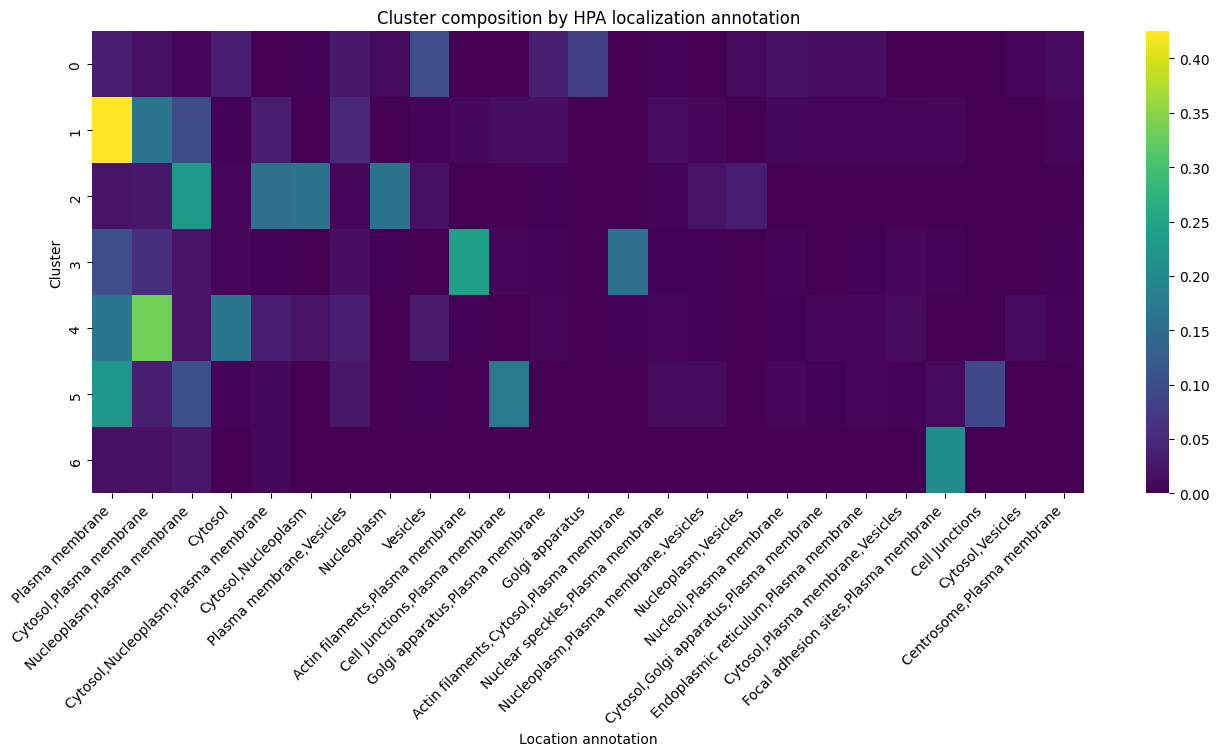

In [236]:
plt.figure(figsize=(16, 6))
sns.heatmap(loc_prop_top, cmap="viridis")
plt.title("Cluster composition by HPA localization annotation")
plt.xlabel("Location annotation")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.show()

In [237]:
for cl in sorted(pm_df["cluster"].unique()):
    print("=" * 60)
    print("CLUSTER", cl)
    print(
        pm_df.loc[pm_df["cluster"] == cl, "genes"]
        .value_counts()
        .head(25)
    )

CLUSTER 0
genes
IRAK4       12
EGFR        11
CLTA         9
SIRT2        9
RRP12        9
BRAF         9
FADS2        8
GCC1         8
VWA5B1       8
ABCB6        8
AAMP         7
MAP7D3       7
KIAA1328     7
IDH3G        6
GPRC5A       6
LMTK2        6
CMTM4        6
NPR1         6
BSDC1        6
NALCN        6
C12orf73     6
SNX15        6
WDR11        6
SDHA         6
KNSTRN       6
Name: count, dtype: int64
CLUSTER 1
genes
MSN           28
EZR           20
CTNNB1        15
EGFR          14
SLC16A1       14
PALM2AKAP2    13
CD44          12
SAMSN1        12
SLC1A5        12
CAVIN1        12
BAIAP2L1      11
TNKS1BP1      11
PPP1R18       11
CSPG4         10
CTNND1        10
MYO1B         10
MARCKS        10
B2M            9
AKAP12         9
ANXA1          9
SCRIB          9
SDC2           9
VIL1           8
CCDC136        8
NCS1           8
Name: count, dtype: int64
CLUSTER 2
genes
ACSS2       13
CEBPE       12
POGZ        12
DLL3        12
KLHL7       12
DNAJC9      12
INTS12    

## 13. Marker Genes and Final Biological Naming
Finally, I inspect representative genes in each cluster and assign cautious biological labels to the embedding-derived clusters.

These labels are not treated as absolute ground truth. They are working biological interpretations based on marker composition, localization enrichment, and known protein functions.

The final cluster names summarize tentative dominant biological themes of each embedding-derived cluster:

- receptor/endocytosis-associated cluster
- cortical surface-associated cluster
- endomembrane-associated cluster
- contractility/cortical-coupling-associated cluster
- signaling/remodeling-associated cluster
- junction/polarity-associated cluster
- focal-adhesion/motility-associated cluster

In [238]:
cluster_labels = {
    0: "receptor_endocytosis_associated",
    1: "cortical_surface_associated",
    2: "endomembrane_associated",
    3: "contractility_cortical_coupling_associated",
    4: "signaling_remodeling_associated",
    5: "junction_polarity_associated",
    6: "focal_adhesion_motility_associated"
}

pm_df["cluster_name"] = pm_df["cluster"].map(cluster_labels)
pm_df[["cluster", "cluster_name"]].drop_duplicates().sort_values("cluster")

,cluster,cluster_name
179,0,receptor_endocytosis_associated
0,1,cortical_surface_associated
80,2,endomembrane_associated
226,3,contractility_cortical_coupling_associated
256,4,signaling_remodeling_associated
32,5,junction_polarity_associated
562,6,focal_adhesion_motility_associated


## 14. Conclusions

This analysis suggests that plasma membrane-associated protein observations in Human Protein Atlas image embedding space are not fully described by a single homogeneous category.

Within the plasma membrane-associated subset, the embeddings show partially separated latent structure.A seven-cluster solution is supported by the evaluated clustering diagnostics among the tested values of `k` and is further examined using bootstrap stability, gene/protein-level summarization, technical bias checks, localization annotations, and functional/signature-based interpretation.

The resulting clusters are best interpreted as embedding-derived localization regimes rather than definitive biological states. They are associated with recognizable cellular themes, including receptor trafficking and endocytosis, cortical membrane organization, cell-cell junctions and polarity, focal adhesion and motility, contractility-related cortical structure, signaling/remodeling, and mixed endomembrane-associated patterns.

Overall, the results support a cautious version of the central hypothesis: plasma membrane-associated protein observations contain reproducible and biologically interpretable latent structure in HPA image embedding space. Further validation would require independent datasets, alternative clustering methods, and direct experimental or literature-based validation of the proposed biological interpretations.